In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
df =sns.load_dataset("mpg")
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [2]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

In [3]:
df["mpg"].describe()

count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

In [4]:
mean_mpg = df["mpg"].mean()
print("Moyenne mpg :", mean_mpg)
#La consommation moyenne des voitures du dataset

Moyenne mpg : 23.514572864321607


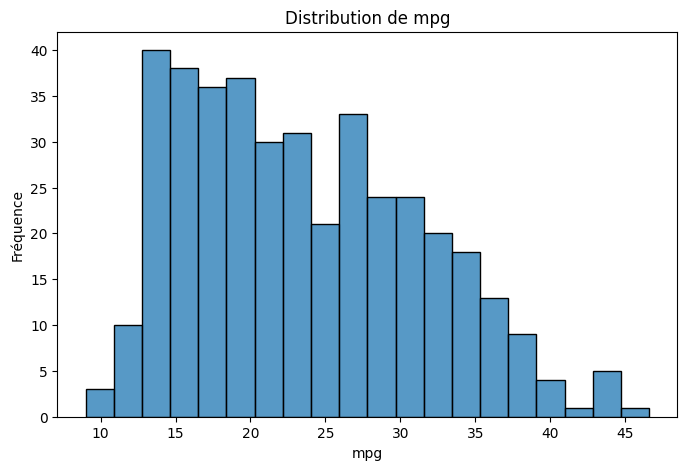

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["mpg"], bins=20)

plt.title("Distribution de mpg")
plt.xlabel("mpg")
plt.ylabel("Fréquence")
plt.show()

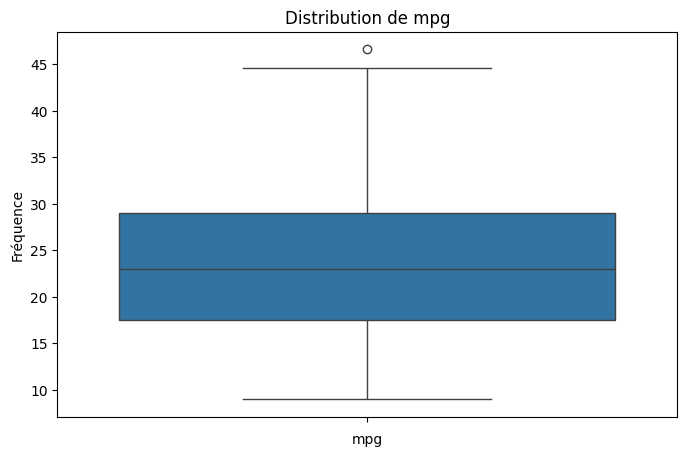

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(df["mpg"])

plt.title("Distribution de mpg")
plt.xlabel("mpg")
plt.ylabel("Fréquence")
plt.show()

In [13]:
#Analysez la variable cylinders
df["cylinders"].value_counts()

cylinders
4    204
8    103
6     84
3      4
5      3
Name: count, dtype: int64

In [8]:

#Analysez la variable origin
df["origin"].value_counts()

origin
usa       249
japan      79
europe     70
Name: count, dtype: int64

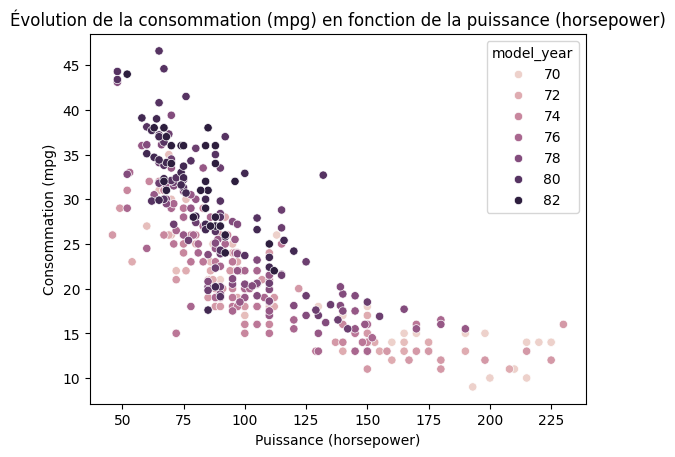

In [14]:
#plt.figure(figsize=(15,6))
sns.scatterplot(data=df, x="horsepower", y="mpg" , hue="model_year")
plt.title("Évolution de la consommation (mpg) en fonction de la puissance (horsepower)")
plt.xlabel("Puissance (horsepower)")
plt.ylabel("Consommation (mpg)")
plt.show()

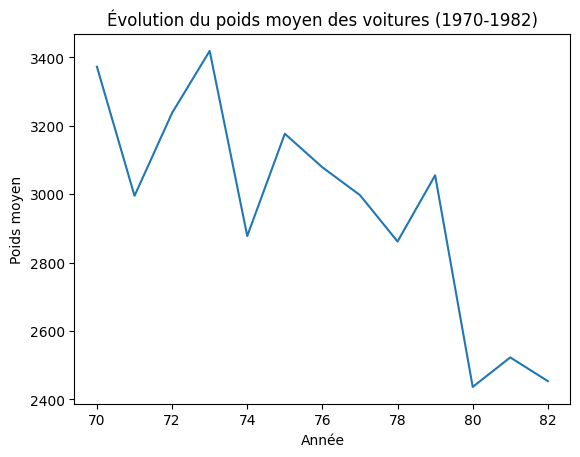

In [ ]:
#l'évolution du poids moyen des voitures américaines de l'année 70 jusqu'à l'année 82
df_filtred= df[(df["model_year"]>=70) & (df["model_year"]<=82)]
df_mean = df_filtred.groupby("model_year")["weight"].mean().reset_index()

sns.lineplot(data=df_mean, x="model_year", y="weight")
plt.title("Évolution du poids moyen des voitures (1970-1982)")
plt.xlabel("Année")
plt.ylabel("Poids moyen")
plt.show()


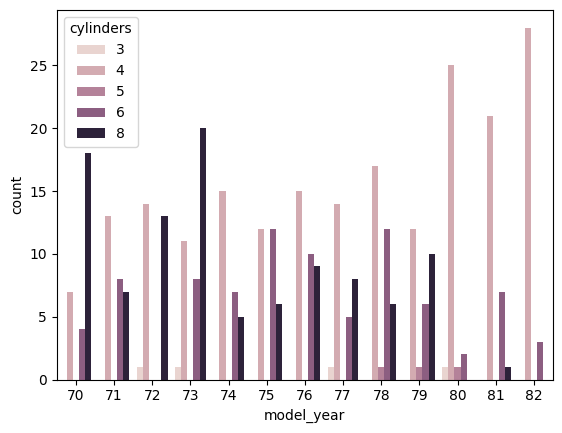

In [15]:
#Analysez la relation entre le nombre de cylindres et l'année du modèle.
sns.countplot(data=df, x="model_year", hue="cylinders")
plt.show()

In [ ]:
##une tendance nette se dégage : le nombre de cylindres diminue au fil des années, traduisant un passage progressif vers des
#  véhicules plus économiques et moins gourmands en carburant.

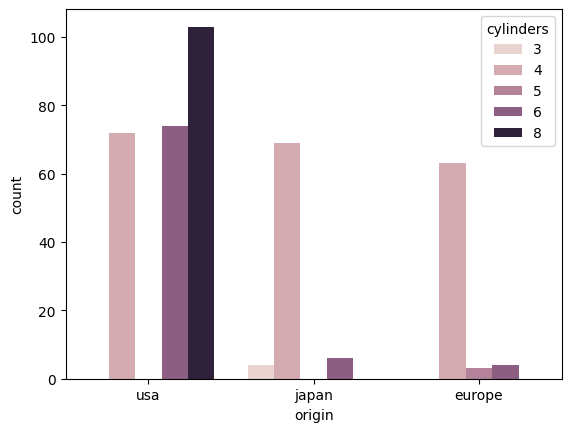

In [19]:
#Analysez la relation entre le nombre de cylindres et l'origine.
sns.countplot(data=df, x="origin", hue="cylinders")
plt.show()

In [ ]:
##On observe une relation nette entre l’origine et le nombre de cylindres : les voitures américaines sont majoritairement équipées de moteurs à 6 ou 8 cylindres, tandis que les voitures japonaises et européennes privilégient les moteurs à 4 cylindres, plus économiques.

In [20]:
#Accélération moyenne par origine
df.groupby("origin")["acceleration"].mean()

origin
europe    16.787143
japan     16.172152
usa       15.033735
Name: acceleration, dtype: float64

In [21]:
#Accélération pour les modèles de 1980
df_80 = df[df["model_year"] == 80]
df_80.groupby("origin")["acceleration"].mean()

origin
europe    18.366667
japan     16.015385
usa       16.800000
Name: acceleration, dtype: float64

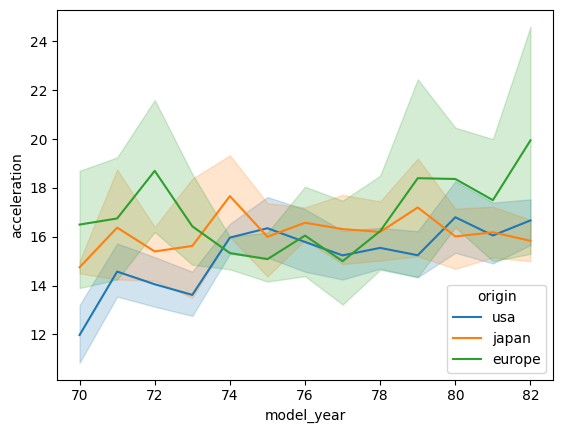

In [22]:
#Tendance dans le temps
sns.lineplot(data=df, x="model_year", y="acceleration", hue="origin")
plt.show()

In [ ]:
"""mpg (consommation) : augmente avec le temps → voitures plus économiques
mpg vs horsepower : relation négative → plus de puissance = plus de consommation
horsepower : diminue globalement avec le temps
horsepower : augmente avec le nombre de cylindres
weight (poids) : diminue avec le temps → voitures plus légères
weight : lié à horsepower et cylindres (plus lourd = plus puissant)
cylinders (cylindres) : diminue avec le temps (8 → 6 → 4)
cylinders vs origine :
USA → 6–8 cylindres
Japon / Europe → 4 cylindres
acceleration : diminue avec le temps → voitures plus rapides
acceleration vs origine :
USA → plus lente
Japon → plus rapide
Europe → intermédiaire
écart entre pays : diminue avec le temps → convergence""""""